In [2]:
import pandas as pd
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

# Load numerical data (assuming whitespace-separated values)
import os 

directory = "..."

file_name = "1 10W 3um_350xsteps_300ysteps_1000msec.dat"
file_path = os.path.join(directory, file_name)
data = pd.read_csv(file_path)
print(data.shape)

(104999, 1340)


In [3]:
data.loc[data.shape[0], :] = 0

In [4]:
# use y and x shape, inverting the order of file name
x_shape = 350
y_shape = 300
arr_data = np.array(data).reshape(y_shape, x_shape, -1)

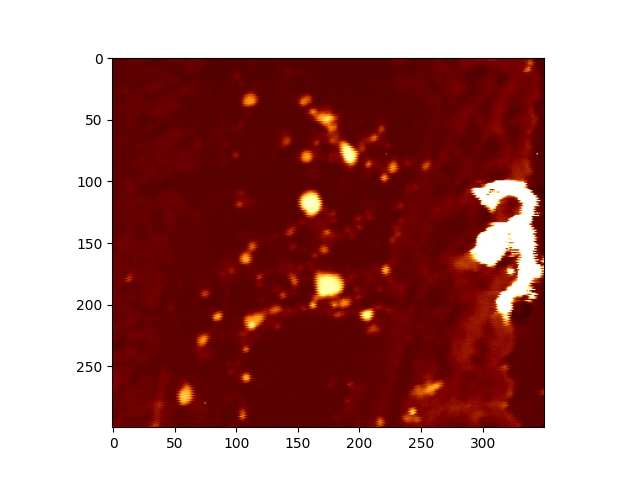

In [12]:
arr_data[1::2] = np.fliplr(arr_data[1::2])
arr_data = np.flip(arr_data, 1)

plt.figure()

vmin = np.percentile(arr_data[:, :, :], 0.01)
vmax = np.percentile(arr_data[:, :, :], 98)

plt.imshow(arr_data[:, :, 555], cmap='afmhot', vmin=vmin, vmax=vmax)
#plt.savefig("H:/Other computers/My Computer/Salvatore/Confocal Raman/test/Polystyrene beads_4/prova.png")

In [13]:
import scipy as sp
import skimage as ski
import pandas as pd

from scipy.signal import savgol_filter
import scipy.signal as sg

def remove_rays(intensity, win_size=9, threshold=90):
    y_out = intensity.copy()
    y_out_med = sg.medfilt(intensity, win_size)
    y_outliers = (y_out-y_out_med)>threshold
    y_out[y_outliers] = y_out_med[y_outliers]

    return y_out

(300, 350, 1340)


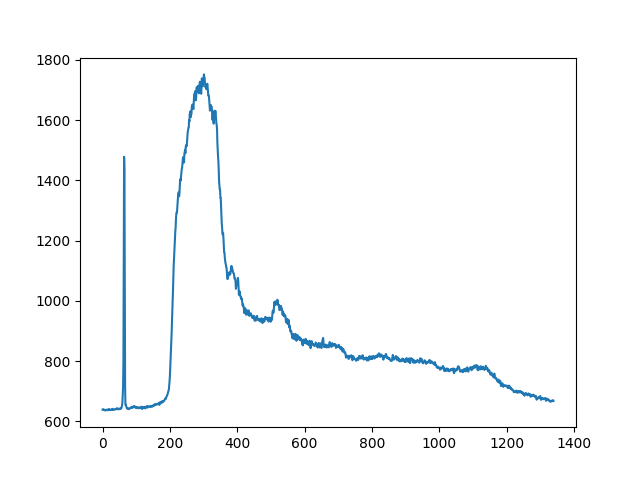

In [14]:
arr_data_proc = np.apply_along_axis(remove_rays, 0, arr_data)
print(arr_data_proc.shape)
arr_data_proc = savgol_filter(arr_data_proc, 5, 3)

plt.figure()

plt.plot(arr_data_proc[161, 137, :])

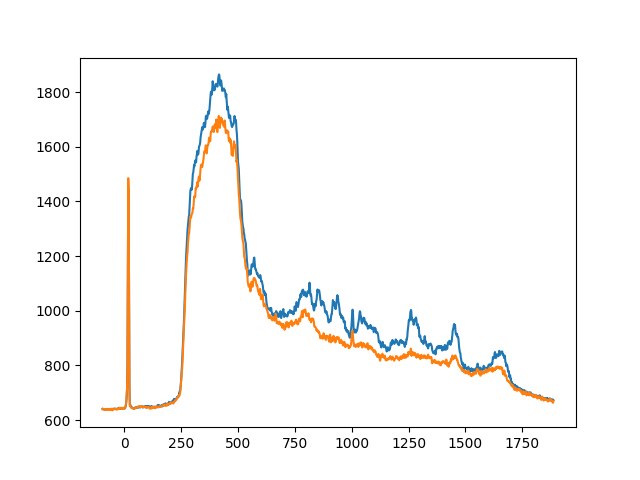

In [64]:
plt.figure()

arr_calibration = pd.read_pickle("H:/Other computers/My Computer/Salvatore/Calibration/arr_calibration.pickle")
plt.plot(arr_calibration, arr_data_proc[231, 288, :])
plt.plot(arr_calibration, arr_data_proc[122, 44, :])

968.7968208430702


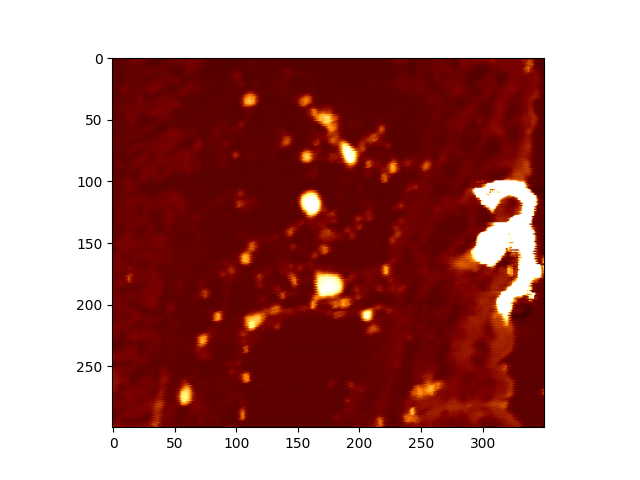

In [30]:
plt.figure()
idx = 633
print(arr_calibration[idx])
vmin = np.percentile(arr_data_proc[:, :, :], 0.1)
vmax = np.percentile(arr_data_proc[:, :, :], 97)
plt.imshow(arr_data_proc[:, :, idx], cmap='afmhot', vmin=vmin, vmax=vmax)

661.7714285714288 2880.7142857142867


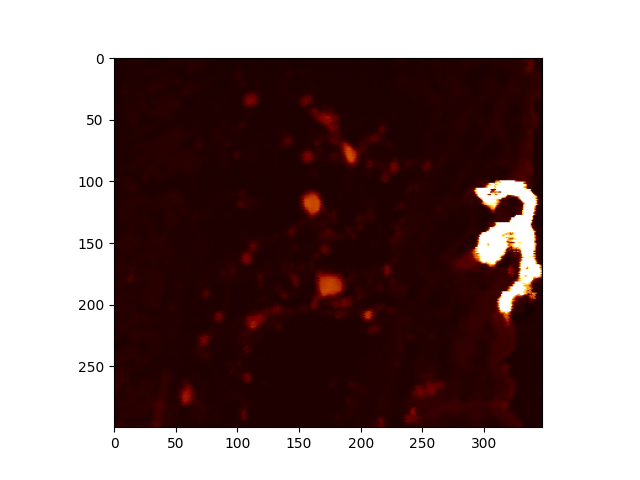

In [20]:
shift = 1
shifted = arr_data_proc.copy()
for i in range(0, arr_data_proc.shape[0], 2):  # 1, 3, 5, ...
    shifted[i, :-shift] = arr_data_proc[i, shift:]      # shift left
    shifted[i, -shift:] = 0   

vmin = np.percentile(shifted[:, :-2, 400:], 0.01)
vmax = np.percentile(shifted[:, :-2, 400:], 99.3)
plt.figure()
idx = 731
plt.imshow(shifted[:, :-2, idx], cmap='afmhot', vmin=vmin, vmax=vmax)
print(vmin, vmax)

In [31]:
import numpy as np
import rampy as rp
from joblib import Parallel, delayed

wv_ind = np.arange(shifted.shape[2])[400:]
roi = np.array([[np.min(wv_ind), np.max(wv_ind)]])
method = 'als'

# Define the function to apply baseline subtraction
def apply_baselinesub(x):
    base, _ = rp.baseline(wv_ind, x, roi, method=method, polynomial_order=3)
    return base.squeeze()

# Reshape the data for vectorized parallel processing
pixels = shifted.reshape(-1, shifted.shape[2])[:, 400:]

# Apply baseline subtraction in parallel
shifted_basesub = Parallel(n_jobs=-1, backend='loky')(
    delayed(apply_baselinesub)(pixel) for pixel in pixels
)

shifted_basesub_resh = np.array(shifted_basesub).reshape(y_shape, x_shape, -1)

(300, 350, 1340)


-55.673367068786135 773.9052283647351


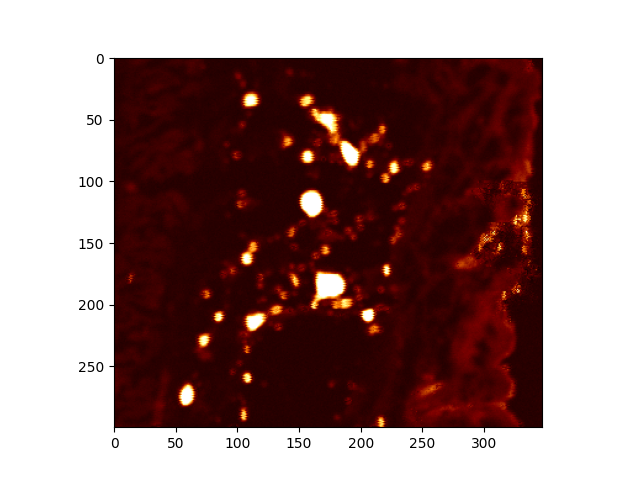

In [47]:
vmin = np.percentile(shifted_basesub_resh[:, :-2, 400:], 0.01)
vmax = np.percentile(shifted_basesub_resh[:, :-2, 400:], 99.9)
plt.figure()
idx = 577
plt.imshow(shifted_basesub_resh[:, :-2, idx], cmap='afmhot', vmin=vmin, vmax=vmax)
print(vmin, vmax)

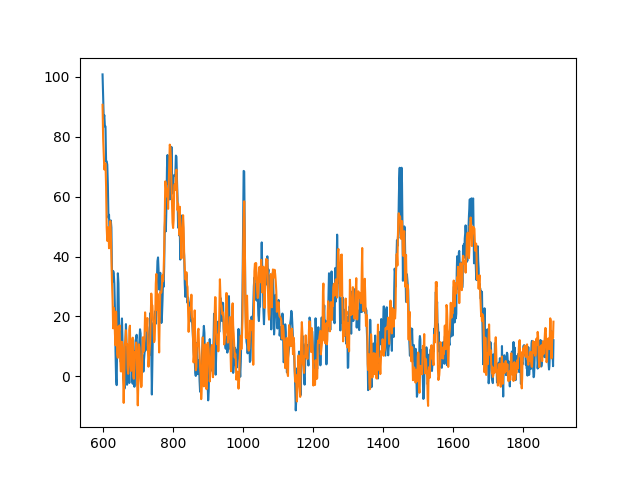

In [66]:
plt.figure()

plt.plot(arr_calibration[400:], shifted_basesub_resh[121, 44, :])
plt.plot(arr_calibration[400:], shifted_basesub_resh[85, 55, :])

-55.673367068786135 580.6324947412614


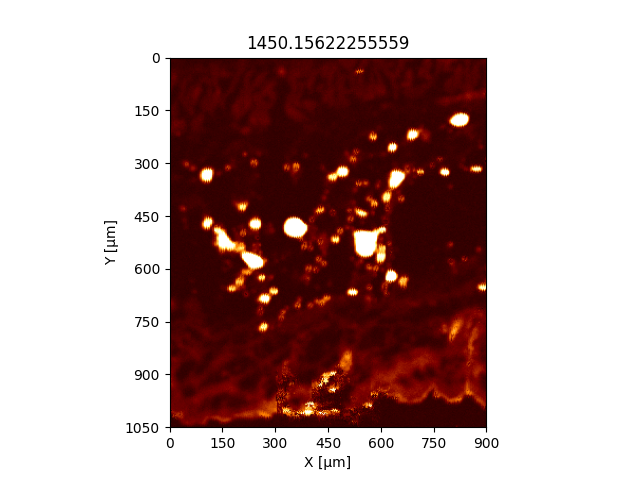

In [70]:
vmin = np.percentile(shifted_basesub_resh[:, :-2, 400:], 0.01)
vmax = np.percentile(shifted_basesub_resh[:, :-2, 400:], 99.82)

idx = 975
pixel_size_um = 3
size_um_x = shifted_basesub_resh.shape[0] * pixel_size_um
size_um_y = shifted_basesub_resh.shape[1] * pixel_size_um

fig, ax = plt.subplots()
ax.imshow(shifted_basesub_resh[:, :-2, idx-400].T, cmap='afmhot', vmin=vmin, vmax=vmax, extent=[0, size_um_x, size_um_y, 0])
ax.set_title(f"{arr_calibration[idx]}")
ticks_um_x = np.arange(0, size_um_x+1, 150)
ticks_um_y = np.arange(0, size_um_y+1, 150)
ax.set_xticks(ticks_um_x)
ax.set_yticks(ticks_um_y)

ax.set_xlabel('X [µm]')
ax.set_ylabel('Y [µm]')

print(vmin, vmax)

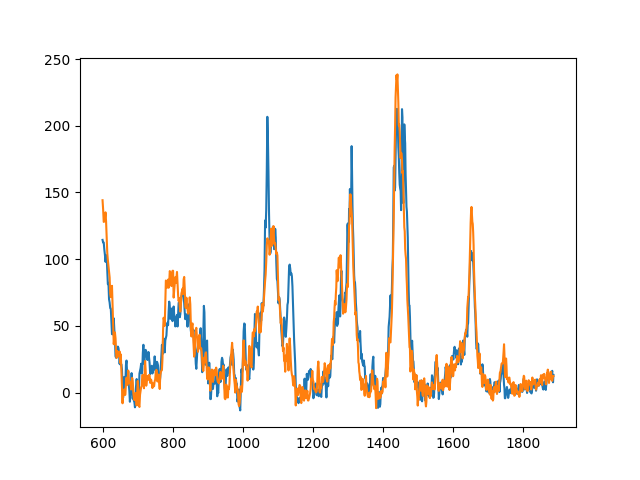

In [25]:
plt.figure()

arr_calibration = pd.read_pickle("H:/Other computers/My Computer/Salvatore/Calibration/arr_calibration.pickle")
plt.plot(arr_calibration[400:], shifted_basesub_resh[113, 247, :])
plt.plot(arr_calibration[400:], shifted_basesub_resh[208, 164, :])